<a href="https://colab.research.google.com/github/imgathuita-hub/python/blob/main/Effects_of_Social_media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==================== 1. IMPORT LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder



In [4]:
df = pd.read_csv('Social_media_impact_on_life.csv')
print(df.shape)                    # (1705, 11)
print(df.columns.tolist())

(1705, 11)
['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact']


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Social_media_impact_on_life.csv to Social_media_impact_on_life.csv


In [5]:
# ==================== 3. DATA EXPLORATION & CLEANING ====================
print(df.info())                   # No missing values!
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB
None
        Student_ID          Age  Avg_Daily_Usage_Hours  S

In [6]:
# Quick value counts
print(df['Overall_Impact'].value_counts())
print(df['Most_Used_Platform'].value_counts().head(10))

Overall_Impact
Negative    939
Positive    499
Neutral     267
Name: count, dtype: int64
Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
Name: count, dtype: int64


In [7]:
# ==================== 4. FEATURE ENGINEERING ====================
# Encode categorical variables for modeling
le_impact = LabelEncoder()
df['Overall_Impact_Encoded'] = le_impact.fit_transform(df['Overall_Impact'])

le_platform = LabelEncoder()
df['Platform_Encoded'] = le_platform.fit_transform(df['Most_Used_Platform'])

# Create a "High_Usage" flag
df['High_Usage'] = (df['Avg_Daily_Usage_Hours'] > 5).astype(int)

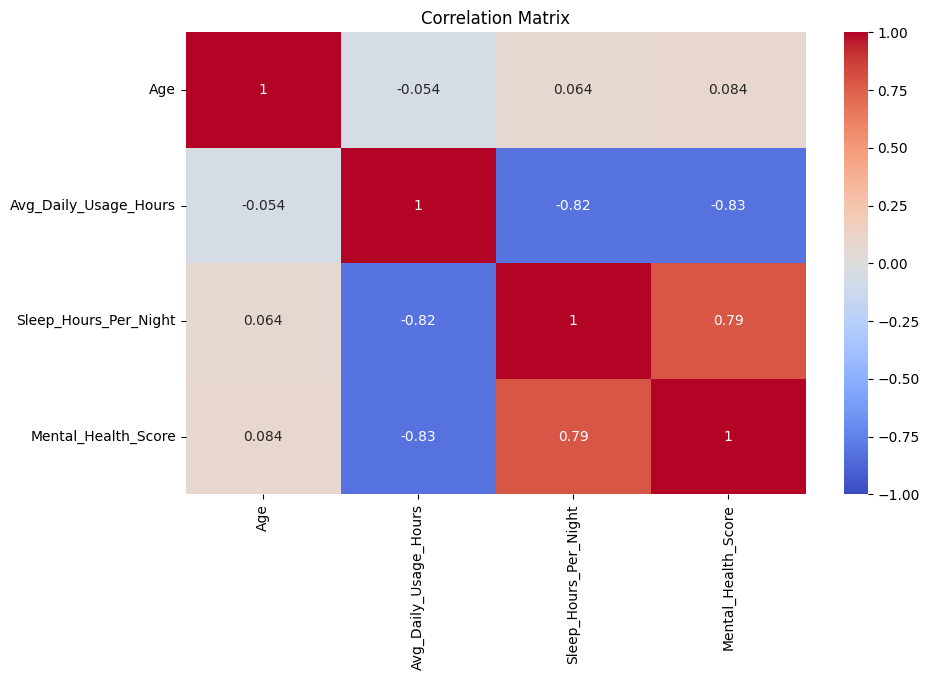

In [8]:
# ==================== 5. EXPLORATORY DATA ANALYSIS (EDA) ====================
# 5.1 Correlation heatmap
plt.figure(figsize=(10, 6))
corr = df[['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
           'Mental_Health_Score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

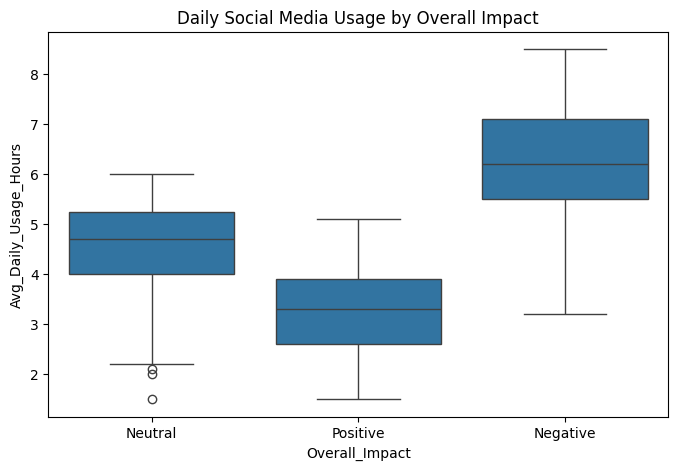

In [9]:
# 5.2 Impact by daily usage
plt.figure(figsize=(8, 5))
sns.boxplot(x='Overall_Impact', y='Avg_Daily_Usage_Hours', data=df)
plt.title('Daily Social Media Usage by Overall Impact')
plt.show()

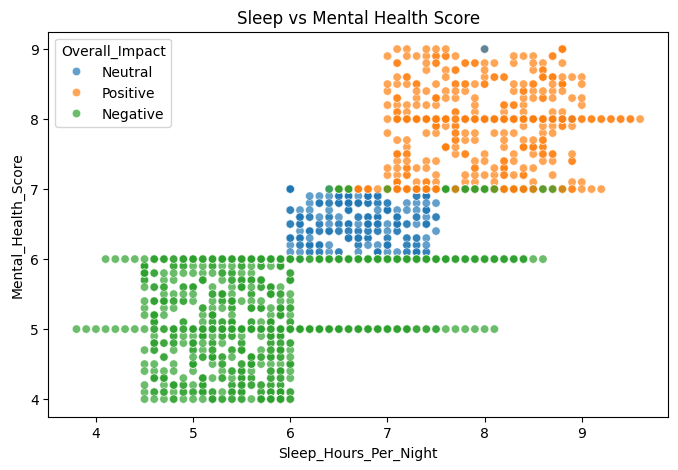

In [10]:
# 5.3 Mental Health vs Sleep (colored by Impact)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score',
                hue='Overall_Impact', data=df, alpha=0.7)
plt.title('Sleep vs Mental Health Score')
plt.show()

In [11]:
# 5.4 Platform impact (percentage)
platform_impact = pd.crosstab(df['Most_Used_Platform'], df['Overall_Impact'],
                              normalize='index') * 100
print(platform_impact.round(1))

Overall_Impact      Negative  Neutral  Positive
Most_Used_Platform                             
Facebook                43.0     14.5      42.6
Instagram               62.0      6.9      31.1
KakaoTalk              100.0      0.0       0.0
LINE                     0.0    100.0       0.0
LinkedIn                33.0     30.1      36.9
Snapchat                54.4     24.8      20.8
TikTok                  73.6      8.8      17.6
Twitter                 45.3     22.9      31.8
VKontakte                0.0      0.0     100.0
WeChat                  53.3      0.0      46.7
WhatsApp               100.0      0.0       0.0
YouTube                 49.1     21.8      29.1


In [12]:
# 5.5 Group statistics
print(df.groupby('Overall_Impact')[['Avg_Daily_Usage_Hours',
                                    'Sleep_Hours_Per_Night',
                                    'Mental_Health_Score']].mean().round(2))

                Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
Overall_Impact                                                 
Negative                         6.22                   5.85   
Neutral                          4.63                   6.80   
Positive                         3.26                   7.90   

                Mental_Health_Score  
Overall_Impact                       
Negative                       5.29  
Neutral                        6.60  
Positive                       7.75  


In [13]:
# Simple OLS regression
X = df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Age']]
X = sm.add_constant(X)
y = df['Mental_Health_Score']

model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.720
Model:                             OLS   Adj. R-squared:                  0.720
Method:                  Least Squares   F-statistic:                     1461.
Date:                 Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                         18:32:44   Log-Likelihood:                -1756.9
No. Observations:                 1705   AIC:                             3522.
Df Residuals:                     1701   BIC:                             3544.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const               

In [14]:
# Features
features = ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
            'Age', 'Platform_Encoded', 'High_Usage']
X = df[features]
y = df['Overall_Impact_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_impact.classes_))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.91      0.95      0.93       197
     Neutral       0.86      0.71      0.77        51
    Positive       0.89      0.90      0.90        93

    accuracy                           0.90       341
   macro avg       0.89      0.85      0.87       341
weighted avg       0.90      0.90      0.90       341

[[187   4   6]
 [ 11  36   4]
 [  7   2  84]]


After uploading the file, you can re-run the cell that reads the CSV to load your data.